In [540]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import PowerTransformer 
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,
                             ConfusionMatrixDisplay,classification_report,roc_auc_score,roc_curve,log_loss)


In [504]:
df = pd.read_csv("../kaggle_files/Titanic dataset zip/Titanic.csv")


In [505]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sex       891 non-null    str    
 1   age       714 non-null    float64
 2   sibsp     891 non-null    int64  
 3   parch     891 non-null    int64  
 4   fare      891 non-null    float64
 5   embarked  889 non-null    str    
 6   class     891 non-null    str    
 7   who       891 non-null    str    
 8   alone     891 non-null    bool   
 9   survived  891 non-null    int64  
dtypes: bool(1), float64(2), int64(3), str(4)
memory usage: 63.6 KB


In [506]:
df['age'] = df['age'].fillna(df['age'].mean())

In [507]:
X = df.drop(columns=['survived'])
Y= df[['survived']]


In [508]:
X_train, X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [509]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sex       891 non-null    str    
 1   age       891 non-null    float64
 2   sibsp     891 non-null    int64  
 3   parch     891 non-null    int64  
 4   fare      891 non-null    float64
 5   embarked  889 non-null    str    
 6   class     891 non-null    str    
 7   who       891 non-null    str    
 8   alone     891 non-null    bool   
 9   survived  891 non-null    int64  
dtypes: bool(1), float64(2), int64(3), str(4)
memory usage: 63.6 KB


In [510]:
X_train['age'].skew()

np.float64(0.3599658846236587)

In [511]:
X_train['parch'].skew()

np.float64(2.6954589914062086)

In [512]:
X_train['sibsp'].skew()

np.float64(3.619385065323857)

In [513]:
X_train['fare'].skew()

np.float64(4.875065571137606)

In [514]:
X_train['sex'].value_counts()

sex
male      467
female    245
Name: count, dtype: int64

In [515]:
X_train['embarked'].value_counts()

embarked
S    525
C    125
Q     60
Name: count, dtype: int64

In [516]:
X_train['class'].value_counts()

class
Third     398
First     163
Second    151
Name: count, dtype: int64

In [517]:
X_train['who'].value_counts()

who
man      432
woman    211
child     69
Name: count, dtype: int64

In [518]:
X_train['alone'].value_counts()

alone
True     429
False    283
Name: count, dtype: int64

In [519]:
df

,sex,age,sibsp,parch,fare,embarked,class,who,alone,survived
0,male,22.000000,1,0,7.2500,S,Third,man,False,0
1,female,38.000000,1,0,71.2833,C,First,woman,False,1
2,female,26.000000,0,0,7.9250,S,Third,woman,True,1
3,female,35.000000,1,0,53.1000,S,First,woman,False,1
4,male,35.000000,0,0,8.0500,S,Third,man,True,0
...,...,...,...,...,...,...,...,...,...,...
886,male,27.000000,0,0,13.0000,S,Second,man,True,0
887,female,19.000000,0,0,30.0000,S,First,woman,True,1
888,female,29.699118,1,2,23.4500,S,Third,woman,False,0
889,male,26.000000,0,0,30.0000,C,First,man,True,1


In [520]:
nominal_encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=True)
nominal_category_columns = ['sex','embarked','who','alone']
X_train_nominal_encoded = nominal_encoder.fit_transform(X_train[nominal_category_columns])
X_test_nominal_encoded =  nominal_encoder.transform(X_test[nominal_category_columns])

In [521]:
ordinal_encoder  = OrdinalEncoder( categories=[['Third','Second','First']])
ordinal_category_columns = ['class']
X_train_ordinal_encoded = ordinal_encoder.fit_transform(X_train[ordinal_category_columns])
X_test_ordinal_encoded = ordinal_encoder.transform(X_test[ordinal_category_columns])

In [522]:
numerical_Transform = PowerTransformer(method='yeo-johnson')
numerical_category_columns = ['age','sibsp','parch','fare']

X_train_numerical_Transformed = numerical_Transform.fit_transform(X_train[numerical_category_columns])
X_test_numerical_Transformed = numerical_Transform.transform(X_test[numerical_category_columns])


In [523]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_numerical_Transformed)
X_test_scaled = scaler.transform(X_test_numerical_Transformed)

In [524]:
X_train_nominal_df = pd.DataFrame.sparse.from_spmatrix(X_train_nominal_encoded, columns= nominal_encoder.get_feature_names_out(nominal_category_columns),index=X_train.index)
X_train_ordinal_df = pd.DataFrame(X_train_ordinal_encoded,columns=ordinal_category_columns,index=X_train.index)


In [525]:
X_train_numerical_df = pd.DataFrame(X_train_scaled,columns=numerical_category_columns,index=X_train.index)


In [526]:
X_test_nominal_df = pd.DataFrame.sparse.from_spmatrix(X_test_nominal_encoded, columns=  
                    nominal_encoder.get_feature_names_out(nominal_category_columns),index=X_test.index)
X_test_ordinal_df = pd.DataFrame(X_test_ordinal_encoded,columns=ordinal_category_columns,index=X_test.index)
X_test_numerical_df = pd.DataFrame(X_test_scaled,columns=numerical_category_columns,index=X_test.index)

In [527]:
X_train_final = pd.concat([X_train_numerical_df, X_train_nominal_df, X_train_ordinal_df],axis=1)
X_train_final.fillna(0,inplace=True)


,age,sibsp,parch,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,embarked_nan,who_child,who_man,who_woman,alone_False,alone_True,class
331,1.206781,-0.683427,-0.561965,0.479998,0,1.0,0,0,1.0,0,0,1.0,0,0,1.0,2.0
733,-0.469258,-0.683427,-0.561965,-0.283753,0,1.0,0,0,1.0,0,0,1.0,0,0,1.0,1.0
382,0.221294,-0.683427,-0.561965,-0.772447,0,1.0,0,0,1.0,0,0,1.0,0,0,1.0,0.0
704,-0.235345,1.350891,-0.561965,-0.781285,0,1.0,0,0,1.0,0,0,1.0,0,1.0,0,0.0
813,-1.911311,1.750636,1.841200,0.568460,1.0,0,0,0,1.0,0,1.0,0,0,1.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,-0.627626,-0.683427,-0.561965,-0.807217,1.0,0,0,0,1.0,0,0,0,1.0,0,1.0,0.0
270,0.047791,-0.683427,-0.561965,0.560073,0,1.0,0,0,1.0,0,0,1.0,0,0,1.0,2.0
860,0.883777,1.633367,-0.561965,-0.203135,0,1.0,0,0,1.0,0,0,1.0,0,1.0,0,0.0
435,-1.200895,1.350891,1.841200,1.783869,1.0,0,0,0,1.0,0,1.0,0,0,1.0,0,2.0


In [528]:
X_test_final = pd.concat([X_test_numerical_df, X_test_nominal_df, X_test_ordinal_df ],axis=1)
X_test_final.fillna(0,inplace=True)

,age,sibsp,parch,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,embarked_nan,who_child,who_man,who_woman,alone_False,alone_True,class
709,0.047791,1.350891,1.723539,-0.126873,0,1.0,1.0,0,0,0,0,1.0,0,1.0,0,0.0
439,0.146118,-0.683427,-0.561965,-0.494669,0,1.0,0,0,1.0,0,0,1.0,0,0,1.0,1.0
840,-0.707613,-0.683427,-0.561965,-0.772447,0,1.0,0,0,1.0,0,0,1.0,0,0,1.0,0.0
720,-1.911311,-0.683427,1.723539,0.619342,1.0,0,0,0,1.0,0,1.0,0,0,1.0,0,1.0
39,-1.200895,1.350891,-0.561965,-0.427219,1.0,0,1.0,0,0,0,1.0,0,0,1.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,-0.951154,-0.683427,-0.561965,-0.877095,0,1.0,0,0,1.0,0,0,1.0,0,0,1.0,0.0
773,0.047791,-0.683427,-0.561965,-0.863410,0,1.0,1.0,0,0,0,0,1.0,0,0,1.0,0.0
25,0.665568,1.350891,1.867615,0.571868,1.0,0,0,0,1.0,0,0,0,1.0,1.0,0,0.0
84,-0.951154,-0.683427,-0.561965,-0.494669,1.0,0,0,0,1.0,0,0,0,1.0,0,1.0,1.0


In [529]:
X_train_final.head(5)

,age,sibsp,parch,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,embarked_nan,who_child,who_man,who_woman,alone_False,alone_True,class
331,1.206781,-0.683427,-0.561965,0.479998,0,1.0,0,0,1.0,0,0,1.0,0,0,1.0,2.0
733,-0.469258,-0.683427,-0.561965,-0.283753,0,1.0,0,0,1.0,0,0,1.0,0,0,1.0,1.0
382,0.221294,-0.683427,-0.561965,-0.772447,0,1.0,0,0,1.0,0,0,1.0,0,0,1.0,0.0
704,-0.235345,1.350891,-0.561965,-0.781285,0,1.0,0,0,1.0,0,0,1.0,0,1.0,0,0.0
813,-1.911311,1.750636,1.841200,0.568460,1.0,0,0,0,1.0,0,1.0,0,0,1.0,0,0.0


In [530]:
model = LogisticRegression(class_weight="balanced")
#model = RandomForestClassifier(n_estimators=100,max_depth=6,class_weight='balanced', random_state=42)

In [531]:
model.fit(X_train_final,Y_train.values.ravel())

c:\Users\Princ\OneDrive\Documents\Projects\python\DataScience\.tutorial_class\Lib\site-packages\sklearn\utils\validation.py:911: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defau

In [532]:
y_pred = model.predict_proba(X_test_final)[:,1]
check = X_test
check['survived'] = Y_test['survived']
check['predict'] = y_pred
check[check['predict']<0] = 0
check['predict']=check['predict'].round()

c:\Users\Princ\OneDrive\Documents\Projects\python\DataScience\.tutorial_class\Lib\site-packages\sklearn\utils\validation.py:911: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [533]:

check.head(50)

,sex,age,sibsp,parch,fare,embarked,class,who,alone,survived,predict
709,male,29.699118,1,1,15.2458,C,Third,man,False,1,0.0
439,male,31.000000,0,0,10.5000,S,Second,man,True,0,0.0
840,male,20.000000,0,0,7.9250,S,Third,man,True,0,0.0
720,female,6.000000,0,1,33.0000,S,Second,child,False,1,1.0
39,female,14.000000,1,0,11.2417,C,Third,child,False,1,1.0
290,female,26.000000,0,0,78.8500,S,First,woman,True,1,1.0
300,female,29.699118,0,0,7.7500,Q,Third,woman,True,1,1.0
333,male,16.000000,2,0,18.0000,S,Third,man,False,0,0.0
208,female,16.000000,0,0,7.7500,Q,Third,woman,True,1,1.0
136,female,19.000000,0,2,26.2833,S,First,woman,False,1,1.0


In [534]:
check.describe()['predict']

count    179.000000
mean       0.491620
std        0.501332
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: predict, dtype: float64

In [569]:
y_pred.std()

np.float64(0.3165235091160655)

In [575]:
threshold_i = 0.40
threshold_proba = (y_pred>threshold_i)

cm = confusion_matrix(Y_test,threshold_proba)
log_loss(Y_test,y_pred)

0.43891345873822013

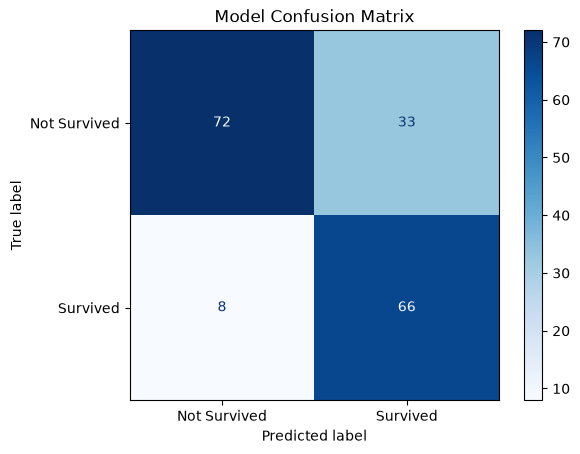

In [576]:
dis = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = ['Not Survived','Survived'])
dis.plot(cmap=plt.cm.Blues)
plt.title("Model Confusion Matrix")
plt.show()

In [577]:
print(f"Accuary Score:{ accuracy_score(Y_test,threshold_proba)}\n Precision Score: {precision_score(Y_test,threshold_proba)} \n Recall Score: {recall_score(Y_test,threshold_proba)}\n F1 Score: {f1_score(Y_test,threshold_proba)}\n  Score: {roc_auc_score(Y_test,threshold_proba)}")

Accuary Score:0.770949720670391
 Precision Score: 0.6666666666666666 
 Recall Score: 0.8918918918918919
 F1 Score: 0.7630057803468208
  Score: 0.7888030888030888


In [573]:
fpr,tpr, threshold = roc_curve(Y_test,threshold_proba)
auc_score = roc_auc_score(Y_test,threshold_proba)
threshold

array([inf,  1.,  0.])

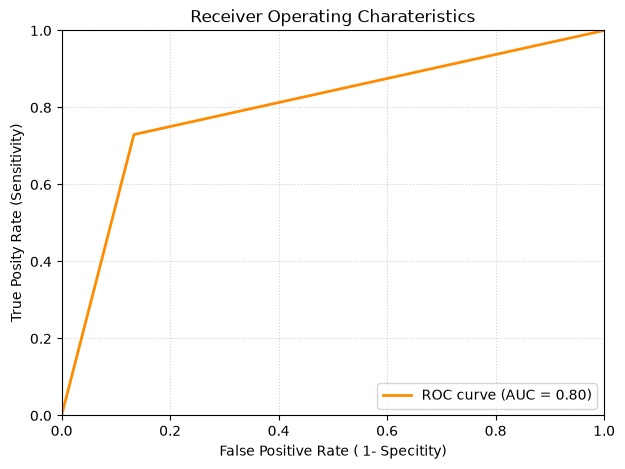

In [574]:
plt.figure(figsize=(7,5))
plt.plot(fpr,tpr, color='darkorange',lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.xlabel("False Positive Rate ( 1- Specitity)")
plt.ylabel("True Posity Rate (Sensitivity)")
plt.title("Receiver Operating Charateristics")
plt.legend(loc="lower right")
plt.grid(True,linestyle=':', alpha=0.6)
plt.show()